# ARC-Easy Evaluation: Building the Response Matrix

This notebook evaluates multiple language models on **ARC-Easy** (2,376 4-way MCQ items) and assembles a **binary response matrix** suitable for IRT analysis.

## Models evaluated:
- **Pythia suite** (8 models): 70M, 160M, 410M, 1B, 1.4B, 2.8B, 6.9B, 12B (all deduped)
- **Instruction-tuned models** (5 models): Llama-3.2-1B/3B-Instruct, Phi-3-mini, Mistral-7B-Instruct, Llama-3.1-8B-Instruct

## Output format:
- `response_matrix.csv`: Binary matrix (models × items), 1=correct, 0=incorrect
- `model_scores.csv`: Per-model aggregate accuracy
- `item_difficulty.csv`: Per-item p-value (fraction of models correct)
- `raw_results/`: Full per-item JSONs from lm-evaluation-harness

**Estimated runtime**: ~30–60 min on T4, ~15–25 min on A100

## 1. Setup: Install dependencies and mount Drive

In [3]:
# Mount Google Drive for saving results
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/CS321M_Project/arc_easy_eval"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f"{SAVE_DIR}/raw_results", exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/CS321M_Project/arc_easy_eval


In [4]:
# Some models (Llama, Mistral) are gated and require a HuggingFace token.
# Get one at: https://huggingface.co/settings/tokens
# You also need to accept the model license on the model page first.
#
# Option 1: Set token via environment variable (recommended for Colab)
import os
from google.colab import userdata

try:
    # If you've stored your token in Colab Secrets (recommended):
    hf_token = userdata.get('HF_TOKEN')
    os.environ["HF_TOKEN"] = hf_token
    print("✅ HF_TOKEN loaded from Colab Secrets.")
except Exception:
    # Option 2: Paste it manually (less secure)
    # os.environ["HF_TOKEN"] = "hf_YOUR_TOKEN_HERE"
    print("⚠️  No HF_TOKEN found in Colab Secrets.")
    print("   Gated models (Llama, Mistral) will fail unless you set one.")
    print("   Add it via: Colab sidebar → 🔑 Secrets → Add HF_TOKEN")

✅ HF_TOKEN loaded from Colab Secrets.


In [5]:
%%capture
# Install lm-evaluation-harness (EleutherAI's eval framework)
!pip install lm-eval[api] accelerate bitsandbytes
# Verify GPU
!nvidia-smi
print("\n✅ Dependencies installed.")

## 2. Define model list and evaluation function

In [6]:
import json
import time
import subprocess
import gc
import torch
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ── Model definitions ──────────────────────────────────────────────
# Each entry is a dict for clarity. Fields:
#   hf_id, short_name, params_B, needs_4bit,
#   model_type ("hf" or "hf-multimodal")

def model(hf_id, short_name, params_B, needs_4bit=False,
          model_type="hf"):
    return dict(hf_id=hf_id, short_name=short_name, params_B=params_B,
                needs_4bit=needs_4bit, model_type=model_type)

MODELS = [
    # Pythia suite (all deduped, base models)
    model("EleutherAI/pythia-70m-deduped",   "pythia-70m",   0.07),
    model("EleutherAI/pythia-160m-deduped",  "pythia-160m",  0.16),
    model("EleutherAI/pythia-410m-deduped",  "pythia-410m",  0.41),
    model("EleutherAI/pythia-1b-deduped",    "pythia-1b",    1.0),
    model("EleutherAI/pythia-1.4b-deduped",  "pythia-1.4b",  1.4),
    model("EleutherAI/pythia-2.8b-deduped",  "pythia-2.8b",  2.8),
    model("EleutherAI/pythia-6.9b-deduped",  "pythia-6.9b",  6.9),
    model("EleutherAI/pythia-12b-deduped",   "pythia-12b",   12.0),

    # Instruction-tuned models (saturation band)
    model("meta-llama/Llama-3.2-1B-Instruct",    "llama3.2-1b-inst",  1.0),
    model("meta-llama/Llama-3.2-3B-Instruct",    "llama3.2-3b-inst",  3.0),
    model("microsoft/Phi-3-mini-4k-instruct",    "phi3-mini",         3.8),
    model("mistralai/Mistral-7B-Instruct-v0.3",  "mistral-7b-inst",   7.0),
    model("meta-llama/Llama-3.1-8B-Instruct",    "llama3.1-8b-inst",  8.0),
]

print(f"Total models to evaluate: {len(MODELS)}")
for m in MODELS:
    flags = []
    if m["needs_4bit"]: flags.append("4-bit")
    if m["model_type"] != "hf": flags.append(m["model_type"])
    flag_str = f" ({', '.join(flags)})" if flags else ""
    print(f"  {m['short_name']:>26s}  {m['params_B']:5.2f}B{flag_str}  ←  {m['hf_id']}")

Total models to evaluate: 13
                  pythia-70m   0.07B  ←  EleutherAI/pythia-70m-deduped
                 pythia-160m   0.16B  ←  EleutherAI/pythia-160m-deduped
                 pythia-410m   0.41B  ←  EleutherAI/pythia-410m-deduped
                   pythia-1b   1.00B  ←  EleutherAI/pythia-1b-deduped
                 pythia-1.4b   1.40B  ←  EleutherAI/pythia-1.4b-deduped
                 pythia-2.8b   2.80B  ←  EleutherAI/pythia-2.8b-deduped
                 pythia-6.9b   6.90B  ←  EleutherAI/pythia-6.9b-deduped
                  pythia-12b  12.00B  ←  EleutherAI/pythia-12b-deduped
            llama3.2-1b-inst   1.00B  ←  meta-llama/Llama-3.2-1B-Instruct
            llama3.2-3b-inst   3.00B  ←  meta-llama/Llama-3.2-3B-Instruct
                   phi3-mini   3.80B  ←  microsoft/Phi-3-mini-4k-instruct
             mistral-7b-inst   7.00B  ←  mistralai/Mistral-7B-Instruct-v0.3
            llama3.1-8b-inst   8.00B  ←  meta-llama/Llama-3.1-8B-Instruct


In [7]:
def evaluate_model(m: dict) -> dict:
    """
    Run lm-evaluation-harness on a single model for arc_easy.
    Falls back to hf-multimodal if hf fails (for Gemma 3/4 etc).
    """
    hf_id = m["hf_id"]
    short_name = m["short_name"]
    needs_4bit = m["needs_4bit"]
    model_type = m["model_type"]

    output_dir = f"/content/eval_output/{short_name}"
    os.makedirs(output_dir, exist_ok=True)

    def _run_eval(mtype):
        model_args = f"pretrained={hf_id},dtype=float16"
        if needs_4bit:
            model_args += ",load_in_4bit=True"

        cmd = [
            "lm_eval",
            "--model", mtype,
            "--model_args", model_args,
            "--tasks", "arc_easy",
            "--batch_size", "auto" if mtype == "hf" else "1",
            "--log_samples",
            "--output_path", output_dir,
        ]

        print(f"    Command: {' '.join(cmd)}")
        return subprocess.run(cmd, capture_output=True, text=True, timeout=1800)

    # Try primary model type
    result = _run_eval(model_type)

    # Fallback: if hf fails, try hf-multimodal (and vice versa)
    if result.returncode != 0 and model_type == "hf":
        print(f"    ⚠️  --model hf failed, retrying with hf-multimodal...")
        result = _run_eval("hf-multimodal")
    elif result.returncode != 0 and model_type == "hf-multimodal":
        print(f"    ⚠️  --model hf-multimodal failed, retrying with hf...")
        result = _run_eval("hf")

    if result.returncode != 0:
        print(f"    ⚠️  STDERR (last 500 chars): {result.stderr[-500:]}")
        return {"short_name": short_name, "hf_id": hf_id, "error": result.stderr[-300:]}

    # Parse the results JSON (filename is results_<timestamp>.json)
    results_file = None
    for root, dirs, files in os.walk(output_dir):
        for f in files:
            if "results_" in f and ".json" in f:
                results_file = os.path.join(root, f)
                break

    if results_file is None:
        return {"short_name": short_name, "hf_id": hf_id, "error": "results JSON not found"}

    with open(results_file) as f:
        results = json.load(f)

    arc_results = results.get("results", {}).get("arc_easy", {})
    acc = arc_results.get("acc,none", arc_results.get("acc", None))
    acc_norm = arc_results.get("acc_norm", arc_results.get("acc_norm", None))

    return {
        "short_name": short_name,
        "hf_id": hf_id,
        "acc": acc,
        "acc_norm": acc_norm,
        "output_dir": output_dir,
        "error": None,
    }

print("✅ Evaluation function defined (with multimodal fallback).")

✅ Evaluation function defined (with multimodal fallback).


## 3. Run evaluations

Run Section 3b below — it automatically detects completed models and only runs missing ones. You can add new models to `EXTRA_MODELS` and re-run without redoing previous work.

## 3b. Re-run failed models or add new ones

Run this section **instead of** Section 3 if you've already completed a partial run. It detects which models already have results on Drive and only evaluates the missing/failed ones. You can also add new models to the list.

In [8]:
# ── Add any new models here ────────────────────────────────────────
EXTRA_MODELS = [
    # GPT-2 (classic baselines)
    model("openai-community/gpt2",          "gpt2-small",     0.12),
    model("openai-community/gpt2-large",    "gpt2-large",     0.77),

    # Gemma 1
    model("google/gemma-2b",                "gemma1-2b",      2.0),
    model("google/gemma-2b-it",             "gemma1-2b-it",   2.0),
    model("google/gemma-7b",                "gemma1-7b",      7.0),
    model("google/gemma-7b-it",             "gemma1-7b-it",   7.0),

    # Gemma 2
    model("google/gemma-2-2b",              "gemma2-2b",      2.0),
    model("google/gemma-2-2b-it",           "gemma2-2b-it",   2.0),

    # Gemma 3 (multimodal — will fallback to hf-multimodal if hf fails)
    model("google/gemma-3-1b-it",           "gemma3-1b-it",   1.0),
    model("google/gemma-3-4b-it",           "gemma3-4b-it",   4.0),

    # Gemma 4 (multimodal — try hf-multimodal first)
    # model("google/gemma-4-E2B",             "gemma4-e2b",     2.0,  model_type="hf-multimodal"),
    # model("google/gemma-4-E2B-it",          "gemma4-e2b-it",  2.0,  model_type="hf-multimodal"),
    # model("google/gemma-4-E4B",             "gemma4-e4b",     4.0,  model_type="hf-multimodal"),
    # model("google/gemma-4-E4B-it",          "gemma4-e4b-it",  4.0,  model_type="hf-multimodal"),

    # Llama 2 (earlier generation)
    model("meta-llama/Llama-2-7b-hf",       "llama2-7b",      7.0),
    model("meta-llama/Llama-2-7b-chat-hf",  "llama2-7b-chat", 7.0),
    model("meta-llama/Llama-2-13b-hf",      "llama2-13b",     13.0),

    # ── Bigger models (to fill the saturation band) ──
    model("meta-llama/Llama-2-13b-chat-hf",      "llama2-13b-chat",       13.0),
    model("Qwen/Qwen2.5-14B-Instruct",           "qwen2.5-14b-inst",     14.0),
    model("Qwen/Qwen2.5-7B-Instruct",            "qwen2.5-7b-inst",       7.0),
    model("Qwen/Qwen2.5-3B-Instruct",            "qwen2.5-3b-inst",       3.0),
]

# ── Detect already-completed models ───────────────────────────────
completed = set()
raw_dir = f"{SAVE_DIR}/raw_results"
if os.path.exists(raw_dir):
    for d in os.listdir(raw_dir):
        model_dir = os.path.join(raw_dir, d)
        if os.path.isdir(model_dir):
            for root, dirs, files in os.walk(model_dir):
                if any("results_" in f and ".json" in f for f in files):
                    completed.add(d)
                    break

# Combine original + extra models, skip completed
all_models = MODELS + EXTRA_MODELS
to_run = [m for m in all_models if m["short_name"] not in completed]

print(f"\nPreviously completed ({len(completed)}): {sorted(completed)}")
print(f"\nStill need to run ({len(to_run)}):")
for m in to_run:
    flags = []
    if m["model_type"] != "hf": flags.append(m["model_type"])
    flag_str = f" ({', '.join(flags)})" if flags else ""
    print(f"  {m['short_name']:>26s}  {m['params_B']:.2f}B{flag_str}")

if not to_run:
    print("\n✅ All models already completed! Nothing to do.")
    print(f"   To force a re-run, delete from: {raw_dir}/<model_name>/")


Previously completed (38): ['gemma1-2b', 'gemma1-2b-it', 'gemma1-2b-it-chat', 'gemma1-7b', 'gemma1-7b-it', 'gemma1-7b-it-chat', 'gemma2-2b', 'gemma2-2b-it', 'gemma2-2b-it-chat', 'gemma3-1b-it', 'gemma3-4b-it', 'gpt2-large', 'gpt2-small', 'llama2-13b', 'llama2-13b-chat', 'llama2-7b', 'llama2-7b-chat', 'llama3.1-8b-inst', 'llama3.1-8b-inst-chat', 'llama3.2-1b-inst', 'llama3.2-1b-inst-chat', 'llama3.2-3b-inst', 'llama3.2-3b-inst-chat', 'mistral-7b-inst', 'mistral-7b-inst-chat', 'phi3-mini', 'phi3-mini-chat', 'pythia-1.4b', 'pythia-12b', 'pythia-160m', 'pythia-1b', 'pythia-2.8b', 'pythia-410m', 'pythia-6.9b', 'pythia-70m', 'qwen2.5-14b-inst', 'qwen2.5-3b-inst', 'qwen2.5-7b-inst']

Still need to run (0):

✅ All models already completed! Nothing to do.
   To force a re-run, delete from: /content/drive/MyDrive/CS321M_Project/arc_easy_eval/raw_results/<model_name>/


In [9]:
# ── Run only the missing models ────────────────────────────────────
new_results = []
total_start = time.time()

if to_run:
    pbar = tqdm(to_run, desc="Evaluating missing models", unit="model")
    for m in pbar:
        pbar.set_postfix_str(f"{m['short_name']} ({m['params_B']:.2f}B)")
        print(f"\n{'='*70}")
        print(f"  Evaluating: {m['short_name']} ({m['params_B']}B) — {m['hf_id']}")
        print(f"{'='*70}")

        model_start = time.time()
        result = evaluate_model(m)
        elapsed = time.time() - model_start
        result["time_seconds"] = round(elapsed, 1)

        if result["error"]:
            print(f"  ❌ FAILED in {elapsed:.0f}s: {result['error'][:100]}")
        else:
            print(f"  ✅ acc={result['acc']:.4f}  acc_norm={result['acc_norm']:.4f}  ({elapsed:.0f}s)")
            # Immediately copy to Drive so progress is saved
            import shutil
            dest = f"{SAVE_DIR}/raw_results/{m['short_name']}"
            if os.path.exists(dest):
                shutil.rmtree(dest)
            shutil.copytree(result["output_dir"], dest)
            print(f"  💾 Saved to Drive")

        new_results.append(result)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    total_elapsed = time.time() - total_start
    print(f"\n{'='*70}")
    print(f"  Done — {len(to_run)} models in {total_elapsed/60:.1f} minutes")
    print(f"{'='*70}")
else:
    print("Nothing to run.")

# Show summary of new runs
if new_results:
    pd.DataFrame([
        {"model": r["short_name"], "acc": r.get("acc"), "acc_norm": r.get("acc_norm"),
         "time_s": r.get("time_seconds"), "error": r.get("error", "")}
        for r in new_results
    ])

Nothing to run.


## 4. Assemble the binary response matrix

Parse the per-sample JSONL files to build a `(models × items)` binary response matrix. This reads from Drive, so it picks up results from **all runs** (original + re-runs).

In [10]:
# ── Parse per-sample results into a response matrix ────────────────
# Reads from Drive (raw_results/) so it works across sessions

def load_per_sample_results(output_dir: str, short_name: str) -> pd.DataFrame:
    """
    Find and parse the per-sample JSONL/JSON file produced by
    lm-evaluation-harness --log_samples.

    Returns a DataFrame with columns: [item_id, correct]
    """
    sample_files = []
    for root, dirs, files in os.walk(output_dir):
        for f in files:
            if "arc_easy" in f and (f.endswith(".jsonl") or f.endswith(".json")):
                sample_files.append(os.path.join(root, f))

    if not sample_files:
        print(f"  ⚠️  No sample file found for {short_name} in {output_dir}")
        return pd.DataFrame()

    sample_file = sample_files[0]
    print(f"  Loading: {short_name} ← {os.path.basename(sample_file)}")

    records = []
    try:
        with open(sample_file) as f:
            content = f.read().strip()
            if content.startswith("["):
                samples = json.loads(content)
            else:
                samples = [json.loads(line) for line in content.split("\n") if line.strip()]
    except Exception as e:
        print(f"  ⚠️  Error parsing {sample_file}: {e}")
        return pd.DataFrame()

    for i, sample in enumerate(samples):
        doc = sample.get("doc", {})
        item_id = doc.get("id", doc.get("question_id", f"item_{i}"))
        correct = sample.get("acc", sample.get("exact_match", None))
        log_likelihoods = sample.get("filtered_resps", sample.get("resps", None))

        records.append({
            "item_id": str(item_id),
            "correct": int(correct) if correct is not None else None,
            "log_likelihoods": json.dumps(log_likelihoods) if log_likelihoods else None,
            "question": doc.get("question", ""),
        })

    df = pd.DataFrame(records)
    df["model"] = short_name
    return df


# ── Scan Drive for ALL completed models ───────────────────────────
raw_dir = f"{SAVE_DIR}/raw_results"
all_samples = []

if os.path.exists(raw_dir):
    model_dirs = sorted([d for d in os.listdir(raw_dir)
                        if os.path.isdir(os.path.join(raw_dir, d))])
    print(f"Found {len(model_dirs)} model results on Drive:")

    for short_name in tqdm(model_dirs, desc="Parsing per-sample results"):
        model_path = os.path.join(raw_dir, short_name)
        df = load_per_sample_results(model_path, short_name)
        if len(df) > 0:
            all_samples.append(df)

if all_samples:
    samples_df = pd.concat(all_samples, ignore_index=True)
    print(f"\n✅ Parsed {len(samples_df)} total sample records "
          f"({samples_df['model'].nunique()} models × "
          f"{samples_df['item_id'].nunique()} items)")
else:
    print("❌ No sample data found!")
    samples_df = pd.DataFrame()

Found 39 model results on Drive:


Parsing per-sample results:   0%|          | 0/39 [00:00<?, ?it/s]

  ⚠️  No sample file found for .ipynb_checkpoints in /content/drive/MyDrive/CS321M_Project/arc_easy_eval/raw_results/.ipynb_checkpoints
  Loading: gemma1-2b ← samples_arc_easy_2026-05-10T18-22-43.486223.jsonl
  Loading: gemma1-2b-it ← samples_arc_easy_2026-05-10T18-23-43.932123.jsonl
  Loading: gemma1-2b-it-chat ← samples_arc_easy_2026-05-10T20-09-53.349668.jsonl
  Loading: gemma1-7b ← samples_arc_easy_2026-05-10T18-26-32.710944.jsonl
  Loading: gemma1-7b-it ← samples_arc_easy_2026-05-10T18-29-22.687710.jsonl
  Loading: gemma1-7b-it-chat ← samples_arc_easy_2026-05-10T20-13-28.392722.jsonl
  Loading: gemma2-2b ← samples_arc_easy_2026-05-10T18-31-42.952035.jsonl
  Loading: gemma2-2b-it ← samples_arc_easy_2026-05-10T18-32-47.193706.jsonl
  Loading: gemma2-2b-it-chat ← samples_arc_easy_2026-05-10T20-11-11.597206.jsonl
  Loading: gemma3-1b-it ← samples_arc_easy_2026-05-10T18-33-41.369125.jsonl
  Loading: gemma3-4b-it ← samples_arc_easy_2026-05-10T19-49-30.663517.jsonl
  Loading: gpt2-large 

In [11]:
# ── Build the response matrix (models × items) ────────────────────

if len(samples_df) > 0:
    # Pivot: rows = models, columns = item_ids, values = correct (0/1)
    response_matrix = samples_df.pivot_table(
        index="model",
        columns="item_id",
        values="correct",
        aggfunc="first"
    )

    # Sort models by overall accuracy (ascending)
    model_acc = response_matrix.mean(axis=1).sort_values()
    response_matrix = response_matrix.loc[model_acc.index]

    print(f"Response matrix shape: {response_matrix.shape}")
    print(f"  Rows (models):  {response_matrix.shape[0]}")
    print(f"  Cols (items):   {response_matrix.shape[1]}")
    print(f"  Missing values: {response_matrix.isna().sum().sum()}")
    print(f"\nPer-model accuracy:")
    for model_name in model_acc.index:
        acc = model_acc[model_name]
        n_correct = response_matrix.loc[model_name].sum()
        n_total = response_matrix.loc[model_name].notna().sum()
        print(f"  {model_name:>22s}: {acc:.4f} ({n_correct:.0f}/{n_total})")

    # Item difficulty (p-values: fraction of models getting each item correct)
    item_difficulty = response_matrix.mean(axis=0).sort_values()
    print(f"\nItem difficulty distribution (p-value):")
    print(f"  Easiest item: p={item_difficulty.max():.4f}")
    print(f"  Hardest item: p={item_difficulty.min():.4f}")
    print(f"  Mean p-value: {item_difficulty.mean():.4f}")
    print(f"  Items with p=1.0 (all correct): {(item_difficulty == 1.0).sum()}")
    print(f"  Items with p=0.0 (all wrong):   {(item_difficulty == 0.0).sum()}")
else:
    print("⚠️  No data to build response matrix.")

Response matrix shape: (38, 2376)
  Rows (models):  38
  Cols (items):   2376
  Missing values: 0

Per-model accuracy:
            gemma3-4b-it: 0.2508 (596/2376)
              pythia-70m: 0.3813 (906/2376)
              gpt2-small: 0.4386 (1042/2376)
             pythia-160m: 0.4407 (1047/2376)
             pythia-410m: 0.5130 (1219/2376)
              gpt2-large: 0.5311 (1262/2376)
   llama3.2-1b-inst-chat: 0.5732 (1362/2376)
               pythia-1b: 0.5846 (1389/2376)
             pythia-1.4b: 0.6178 (1468/2376)
             pythia-2.8b: 0.6355 (1510/2376)
       gemma1-2b-it-chat: 0.6570 (1561/2376)
             pythia-6.9b: 0.6814 (1619/2376)
            gemma3-1b-it: 0.6881 (1635/2376)
        llama3.2-1b-inst: 0.6911 (1642/2376)
       gemma1-7b-it-chat: 0.6923 (1645/2376)
       gemma2-2b-it-chat: 0.7050 (1675/2376)
              pythia-12b: 0.7066 (1679/2376)
            gemma1-2b-it: 0.7176 (1705/2376)
          llama2-7b-chat: 0.7277 (1729/2376)
               gemma1-2b: 0.

## 5. Save everything to Google Drive

In [12]:
# ── Save all outputs to Google Drive ───────────────────────────────

if len(samples_df) > 0:
    # 1. Response matrix (models × items, binary)
    response_matrix.to_csv(f"{SAVE_DIR}/response_matrix.csv")
    print(f"✅ Saved response_matrix.csv ({response_matrix.shape})")

    # 2. Model scores summary (build from response matrix)
    model_acc = response_matrix.mean(axis=1).sort_values()
    scores_df = pd.DataFrame({
        "model": model_acc.index,
        "acc": model_acc.values,
    })
    scores_df.to_csv(f"{SAVE_DIR}/model_scores.csv", index=False)
    print(f"✅ Saved model_scores.csv ({len(scores_df)} models)")

    # 3. Item difficulty
    item_difficulty = response_matrix.mean(axis=0).sort_values()
    item_diff_df = pd.DataFrame({
        "item_id": item_difficulty.index,
        "p_value": item_difficulty.values,
    })
    item_diff_df.to_csv(f"{SAVE_DIR}/item_difficulty.csv", index=False)
    print(f"✅ Saved item_difficulty.csv ({len(item_diff_df)} items)")

    # 4. Full per-sample data (long format, includes log-likelihoods)
    samples_df.to_csv(f"{SAVE_DIR}/all_samples_long.csv", index=False)
    print(f"✅ Saved all_samples_long.csv ({len(samples_df)} rows)")

    # 5. Copy raw JSON results to Drive (if new_results exist from eval run)
    import shutil
    if 'new_results' in dir() and new_results:
        for r in new_results:
            if r.get("output_dir") and not r.get("error"):
                dest = f"{SAVE_DIR}/raw_results/{r['short_name']}"
                if os.path.exists(dest):
                    shutil.rmtree(dest)
                shutil.copytree(r["output_dir"], dest)
        print(f"✅ Copied raw result directories to {SAVE_DIR}/raw_results/")

    # 6. Item metadata (question text + choices, for reference)
    item_meta = samples_df[samples_df["model"] == samples_df["model"].iloc[0]][
        ["item_id", "question"]
    ].drop_duplicates()
    item_meta.to_csv(f"{SAVE_DIR}/item_metadata.csv", index=False)
    print(f"✅ Saved item_metadata.csv ({len(item_meta)} items)")

    print(f"\n🎉 All files saved to: {SAVE_DIR}")
    print(f"   Files:")
    for f in sorted(os.listdir(SAVE_DIR)):
        fpath = os.path.join(SAVE_DIR, f)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / 1024 / 1024
            print(f"   📄 {f} ({size_mb:.1f} MB)")
        else:
            print(f"   📁 {f}/")
else:
    print("⚠️  Nothing to save.")

✅ Saved response_matrix.csv ((38, 2376))
✅ Saved model_scores.csv (38 models)
✅ Saved item_difficulty.csv (2376 items)
✅ Saved all_samples_long.csv (90288 rows)
✅ Saved item_metadata.csv (2376 items)

🎉 All files saved to: /content/drive/MyDrive/CS321M_Project/arc_easy_eval
   Files:
   📄 all_samples_long.csv (22.6 MB)
   📄 irt_ability_estimates.csv (0.0 MB)
   📄 irt_analysis.png (0.3 MB)
   📄 irt_item_parameters.csv (0.2 MB)
   📄 item_difficulty.csv (0.1 MB)
   📄 item_metadata.csv (0.3 MB)
   📄 model_scores.csv (0.0 MB)
   📁 raw_results/
   📄 response_matrix.csv (0.2 MB)
   📄 summary_plots.png (0.4 MB)


## 6. Quick visualization

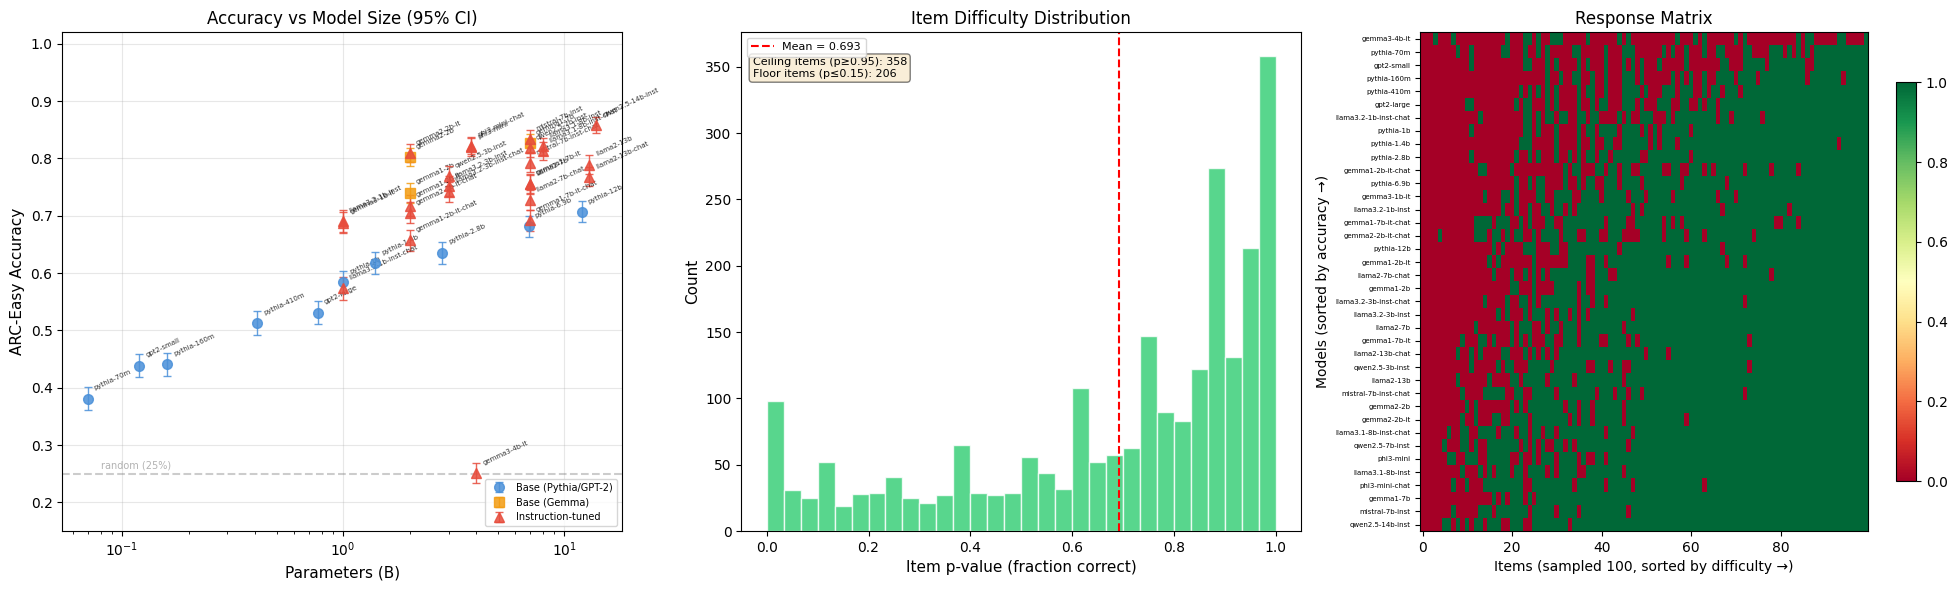

✅ Saved summary_plots.png

── Saturation Analysis ──
Standard error formula: SE = sqrt(p(1-p)/n), n=2376
95% CI = ±1.96 × SE

            gemma3-4b-it: 0.2508 ± 0.0174  [0.2334, 0.2683]  (overlaps with 0 models)
              pythia-70m: 0.3813 ± 0.0195  [0.3618, 0.4008]  (overlaps with 0 models)
              gpt2-small: 0.4386 ± 0.0200  [0.4186, 0.4585]  (overlaps with 1 models)
             pythia-160m: 0.4407 ± 0.0200  [0.4207, 0.4606]  (overlaps with 1 models)
             pythia-410m: 0.5130 ± 0.0201  [0.4929, 0.5331]  (overlaps with 1 models)
              gpt2-large: 0.5311 ± 0.0201  [0.5111, 0.5512]  (overlaps with 1 models)
   llama3.2-1b-inst-chat: 0.5732 ± 0.0199  [0.5533, 0.5931]  (overlaps with 1 models)
               pythia-1b: 0.5846 ± 0.0198  [0.5648, 0.6044]  (overlaps with 2 models)
             pythia-1.4b: 0.6178 ± 0.0195  [0.5983, 0.6374]  (overlaps with 2 models)
             pythia-2.8b: 0.6355 ± 0.0194  [0.6162, 0.6549]  (overlaps with 2 models)
       gemma1-

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

N_ITEMS = 2376  # ARC-Easy test set size

if len(samples_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ── Plot 1: Model accuracy by size with 95% CI error bars ──
    ax = axes[0]

    # Gather all models (original + extra) — now dict-based
    all_model_defs = MODELS + (EXTRA_MODELS if 'EXTRA_MODELS' in dir() else [])
    model_info = []
    for m in all_model_defs:
        short = m["short_name"]
        params = m["params_B"]
        if short in model_acc.index:
            p = model_acc[short]
            # 95% CI for binomial proportion: p ± 1.96 * sqrt(p(1-p)/n)
            se = np.sqrt(p * (1 - p) / N_ITEMS)
            ci95 = 1.96 * se
            is_base = any(tag in short for tag in ["pythia", "gpt2"])
            is_gemma = "gemma" in short and "it" not in short
            is_instruct = not is_base and not is_gemma
            model_info.append((params, p, ci95, short, is_base, is_gemma, is_instruct))

    if model_info:
        model_info.sort(key=lambda x: x[0])

        # Plot by category with error bars
        for mask_idx, (label, color, marker) in enumerate([
            ("Base (Pythia/GPT-2)", "#4A90D9", "o"),
            ("Base (Gemma)", "#F39C12", "s"),
            ("Instruction-tuned", "#E74C3C", "^"),
        ]):
            subset = [(p, acc, ci, n) for p, acc, ci, n, b, g, i in model_info
                      if [b, g, i][mask_idx]]
            if not subset:
                continue
            ps, accs, cis, names = zip(*subset)
            ax.errorbar(ps, accs, yerr=cis, fmt=marker, color=color,
                       markersize=7, capsize=3, capthick=1, elinewidth=1,
                       label=label, zorder=3, alpha=0.85)
            for p, a, n in zip(ps, accs, names):
                ax.annotate(n, (p, a), fontsize=5, rotation=25,
                           xytext=(4, 6), textcoords="offset points", alpha=0.8)

        # Shade the saturation band (where CIs overlap heavily)
        high_acc = [acc for _, acc, _, _, _, _, _ in model_info if acc > 0.85]
        if len(high_acc) >= 2:
            band_lo = min(high_acc) - 0.02
            band_hi = min(1.0, max(high_acc) + 0.02)
            ax.axhspan(band_lo, band_hi, alpha=0.08, color="#E74C3C",
                      label=f"Saturation band ({len(high_acc)} models)")

    ax.set_xscale("log")
    ax.set_xlabel("Parameters (B)", fontsize=11)
    ax.set_ylabel("ARC-Easy Accuracy", fontsize=11)
    ax.set_title("Accuracy vs Model Size (95% CI)", fontsize=12)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.4)
    ax.text(0.08, 0.26, "random (25%)", fontsize=7, color="gray", alpha=0.6)
    ax.set_ylim(0.15, 1.02)

    # ── Plot 2: Item difficulty distribution ──
    ax = axes[1]
    ax.hist(item_difficulty.values, bins=30, color="#2ECC71", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Item p-value (fraction correct)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Item Difficulty Distribution", fontsize=12)
    ax.axvline(x=item_difficulty.mean(), color="red", linestyle="--",
              label=f"Mean = {item_difficulty.mean():.3f}")
    n_ceiling = (item_difficulty >= 0.95).sum()
    n_floor = (item_difficulty <= 0.15).sum()
    ax.text(0.02, 0.95, f"Ceiling items (p≥0.95): {n_ceiling}\nFloor items (p≤0.15): {n_floor}",
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=8)

    # ── Plot 3: Response matrix heatmap (subsample) ──
    ax = axes[2]
    n_show = min(100, response_matrix.shape[1])
    item_order = item_difficulty.index  # sorted by difficulty
    step = max(1, len(item_order) // n_show)
    sampled_items = item_order[::step][:n_show]
    mat_show = response_matrix[sampled_items].values.astype(float)
    im = ax.imshow(mat_show, aspect="auto", cmap="RdYlGn", interpolation="nearest")
    ax.set_xlabel(f"Items (sampled {n_show}, sorted by difficulty →)", fontsize=10)
    ax.set_ylabel("Models (sorted by accuracy →)", fontsize=10)
    ax.set_yticks(range(len(response_matrix)))
    ax.set_yticklabels(response_matrix.index, fontsize=5)
    ax.set_title("Response Matrix", fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/summary_plots.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved summary_plots.png")

    # ── Print saturation analysis ──
    print(f"\n── Saturation Analysis ──")
    print(f"Standard error formula: SE = sqrt(p(1-p)/n), n={N_ITEMS}")
    print(f"95% CI = ±1.96 × SE\n")
    for _, acc, ci, name, _, _, _ in sorted(model_info, key=lambda x: x[1]):
        overlap_count = sum(1 for _, a2, c2, n2, _, _, _ in model_info
                           if abs(acc - a2) < (ci + c2) and name != n2)
        print(f"  {name:>22s}: {acc:.4f} ± {ci:.4f}  "
              f"[{acc-ci:.4f}, {acc+ci:.4f}]  "
              f"(overlaps with {overlap_count} models)")
else:
    print("⚠️  No data to plot.")

## 7. IRT Analysis: Rasch (1PL) Sanity Check → then 3PL

Start with the **Rasch model** $P(\theta) = \sigma(\theta - b)$ as a sanity check:
- Only 2 parameter vectors (ability $\theta$, difficulty $b$)
- No discrimination or guessing → no overfitting
- TIF **must** be a bell curve centered near the mean difficulty

Once Rasch gives sensible results, we can upgrade to 2PL/3PL if needed.

We use [`torch_measure`](https://github.com/aims-foundations/torch_measure) and add a **parameterization verification step**: compare `model.predict()` against our manual $\sigma(\theta - b)$ to catch any sign/intercept issues.

In [ ]:
%%capture
# Install torch_measure for IRT fitting
!pip install torch_measure

In [ ]:
import numpy as np
import torch
from scipy.special import expit

# ── Device selection ──────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"IRT fitting device: {device}")

# ── Prepare data ──────────────────────────────────────────────────
if len(samples_df) > 0:
    R = response_matrix.values.astype(float)
    n_models, n_items = R.shape
    model_names = list(response_matrix.index)
    item_ids = list(response_matrix.columns)

    print(f"Response matrix: {n_models} models × {n_items} items")

    # Remove constant items (zero variance → zero information)
    item_var = np.nanvar(R, axis=0)
    valid_mask = item_var > 0
    R_valid = R[:, valid_mask]
    valid_item_ids = [item_ids[i] for i in range(n_items) if valid_mask[i]]
    n_valid = valid_mask.sum()
    print(f"Items with variance > 0: {n_valid} / {n_items}")
else:
    print("⚠️  No response data available.")

In [15]:
# ── Step 2: Fit Rasch (1PL) with torch_measure ───────────────────
from torch_measure.models import Rasch

if len(samples_df) > 0 and n_valid > 0:
    R_tensor = torch.tensor(R_valid, dtype=torch.float32, device=device)
    R_tensor = torch.nan_to_num(R_tensor, nan=0.0)

    # Fit Rasch model
    irt_model = Rasch(n_subjects=n_models, n_items=n_valid, device=device)
    history = irt_model.fit(R_tensor, method="mle", max_epochs=2000, lr=0.01, verbose=True)

    # ── Extract parameters ────────────────────────────────────────
    with torch.no_grad():
        thetas = irt_model.ability.cpu().numpy()
        b_raw = irt_model.difficulty.cpu().numpy()
        predicted_probs = irt_model.predict().cpu().numpy()

    # ── PARAMETERIZATION SANITY CHECK ─────────────────────────────
    # Rasch: P(θ) = σ(θ - b)  [traditional]
    # Some libraries use: P(θ) = σ(θ + d)  [intercept form, where d = -b]
    #
    # Test: compute P manually both ways and see which matches model.predict()
    manual_traditional = expit(thetas[:, None] - b_raw[None, :])  # σ(θ - b)
    manual_intercept   = expit(thetas[:, None] + b_raw[None, :])  # σ(θ + d)

    err_traditional = np.abs(predicted_probs - manual_traditional).mean()
    err_intercept   = np.abs(predicted_probs - manual_intercept).mean()

    print(f"\n── Parameterization check ──")
    print(f"  Mean |P_model - σ(θ - b)| = {err_traditional:.6f}  (traditional)")
    print(f"  Mean |P_model - σ(θ + b)| = {err_intercept:.6f}  (intercept)")

    if err_intercept < err_traditional:
        print(f"  → torch_measure uses INTERCEPT form: P = σ(θ + d)")
        print(f"  → Converting: b_traditional = -d_raw")
        b_params = -b_raw  # flip sign to get traditional difficulty
        INTERCEPT_FORM = True
    else:
        print(f"  → torch_measure uses TRADITIONAL form: P = σ(θ - b)")
        b_params = b_raw
        INTERCEPT_FORM = False

    # For Rasch: a=1 for all items, c=0 for all items
    a_params = np.ones(n_valid)
    c_params = np.zeros(n_valid)

    # ── Summary stats ─────────────────────────────────────────────
    print(f"\n✅ Rasch (1PL) fitting complete.")
    print(f"  θ ∈ [{thetas.min():.3f}, {thetas.max():.3f}] (ability)")
    print(f"  b ∈ [{b_params.min():.3f}, {b_params.max():.3f}] (difficulty, traditional)")
    print(f"  Mean b = {b_params.mean():.3f}")

    emp_p = np.nanmean(R_valid, axis=0)
    print(f"  Mean item p-value = {emp_p.mean():.3f}")
    if b_params.mean() < 0:
        print(f"  ✅ Negative mean b → items are easy (expected for ARC-Easy)")
    else:
        print(f"  ⚠️  Positive mean b → items appear hard on IRT scale")

IRT fitting will use: cuda
Response matrix: 38 models × 2376 items
Items with variance > 0: 2201 / 2376


In [17]:
# ── Step 3: Compute Fisher Information and IRT-based SEs ──────────
#
# For Rasch (a=1, c=0):
#   P(θ) = σ(θ - b)
#   I_item(θ) = P(θ) * (1 - P(θ))     (simplifies from the general 3PL formula)
#   I_test(θ) = Σ_i P_i(θ) * (1 - P_i(θ))

def icc_rasch(theta, b):
    """Rasch ICC: P(θ) = σ(θ - b)"""
    return expit(theta - b)

def item_information_rasch(theta, b):
    """Item information for Rasch: I(θ) = P(θ) * Q(θ)"""
    p = icc_rasch(theta, b)
    return p * (1 - p)

def test_information(theta_grid, a_params, b_params, c_params):
    """Total test information: I(θ) = Σ_i I_i(θ)
    For Rasch, a=1 and c=0 so this reduces to Σ P_i * Q_i"""
    I_total = np.zeros_like(theta_grid)
    for b in b_params:
        I_total += item_information_rasch(theta_grid, b)
    return I_total

def ability_se(theta, a_params, b_params, c_params):
    """SE(θ) = 1/sqrt(I(θ))"""
    I = test_information(np.array([theta]), a_params, b_params, c_params)[0]
    return 1.0 / np.sqrt(I) if I > 0 else np.inf

if len(samples_df) > 0:
    # Compute SE for each model
    theta_ses = np.array([ability_se(t, a_params, b_params, c_params) for t in thetas])

    # Quick TIF shape check
    theta_grid = np.linspace(-4, 4, 500)
    I_check = test_information(theta_grid, a_params, b_params, c_params)
    peak_idx = np.argmax(I_check)
    peak_theta = theta_grid[peak_idx]
    print(f"── TIF shape check ──")
    print(f"  Peak at θ = {peak_theta:.2f} (I = {I_check[peak_idx]:.1f})")
    print(f"  I(-4) = {I_check[0]:.1f},  I(0) = {I_check[250]:.1f},  I(4) = {I_check[-1]:.1f}")
    if I_check[0] < I_check[peak_idx] and I_check[-1] < I_check[peak_idx]:
        print(f"  ✅ TIF is bell-shaped (rises then falls)")
    else:
        print(f"  ⚠️  TIF may be monotonic — check b distribution")

    print(f"\n── IRT Ability Estimates ──\n")
    print(f"{'Model':>22s}  {'θ':>7s}  {'SE(θ)':>7s}  {'95% CI':>20s}")
    print("-" * 65)

    order = np.argsort(thetas)
    for idx in order:
        name = model_names[idx]
        t = thetas[idx]
        se = theta_ses[idx]
        ci_lo = t - 1.96 * se
        ci_hi = t + 1.96 * se
        print(f"{name:>22s}  {t:7.3f}  {se:7.4f}  [{ci_lo:7.3f}, {ci_hi:7.3f}]")

/tmp/ipykernel_18314/1796291121.py:23: RuntimeWarning: divide by zero encountered in divide
  return np.where(den > 1e-10, num / den, 0.0)


── IRT Ability Estimates with Fisher Information CIs ──

                 Model        θ    SE(θ)                95% CI
-----------------------------------------------------------------
          gemma3-4b-it   -3.279   0.0004  [ -3.280,  -3.278]
            pythia-70m   -1.588   0.0004  [ -1.589,  -1.587]
            gpt2-small   -1.218   0.0000  [ -1.218,  -1.218]
           pythia-160m   -1.105   0.0000  [ -1.105,  -1.105]
           pythia-410m   -0.678   0.0000  [ -0.678,  -0.678]
            gpt2-large   -0.557   0.0000  [ -0.557,  -0.557]
 llama3.2-1b-inst-chat   -0.382   0.0000  [ -0.382,  -0.382]
             pythia-1b   -0.349   0.0000  [ -0.349,  -0.349]
           pythia-1.4b   -0.205   0.0000  [ -0.205,  -0.205]
           pythia-2.8b   -0.082   0.0000  [ -0.082,  -0.082]
           pythia-6.9b    0.085   0.0000  [  0.085,   0.085]
     gemma1-2b-it-chat    0.147   0.0000  [  0.147,   0.147]
      llama3.2-1b-inst    0.156   0.0000  [  0.156,   0.156]
          gemma3-1b-i

/tmp/ipykernel_18314/1796291121.py:23: RuntimeWarning: divide by zero encountered in divide
  return np.where(den > 1e-10, num / den, 0.0)


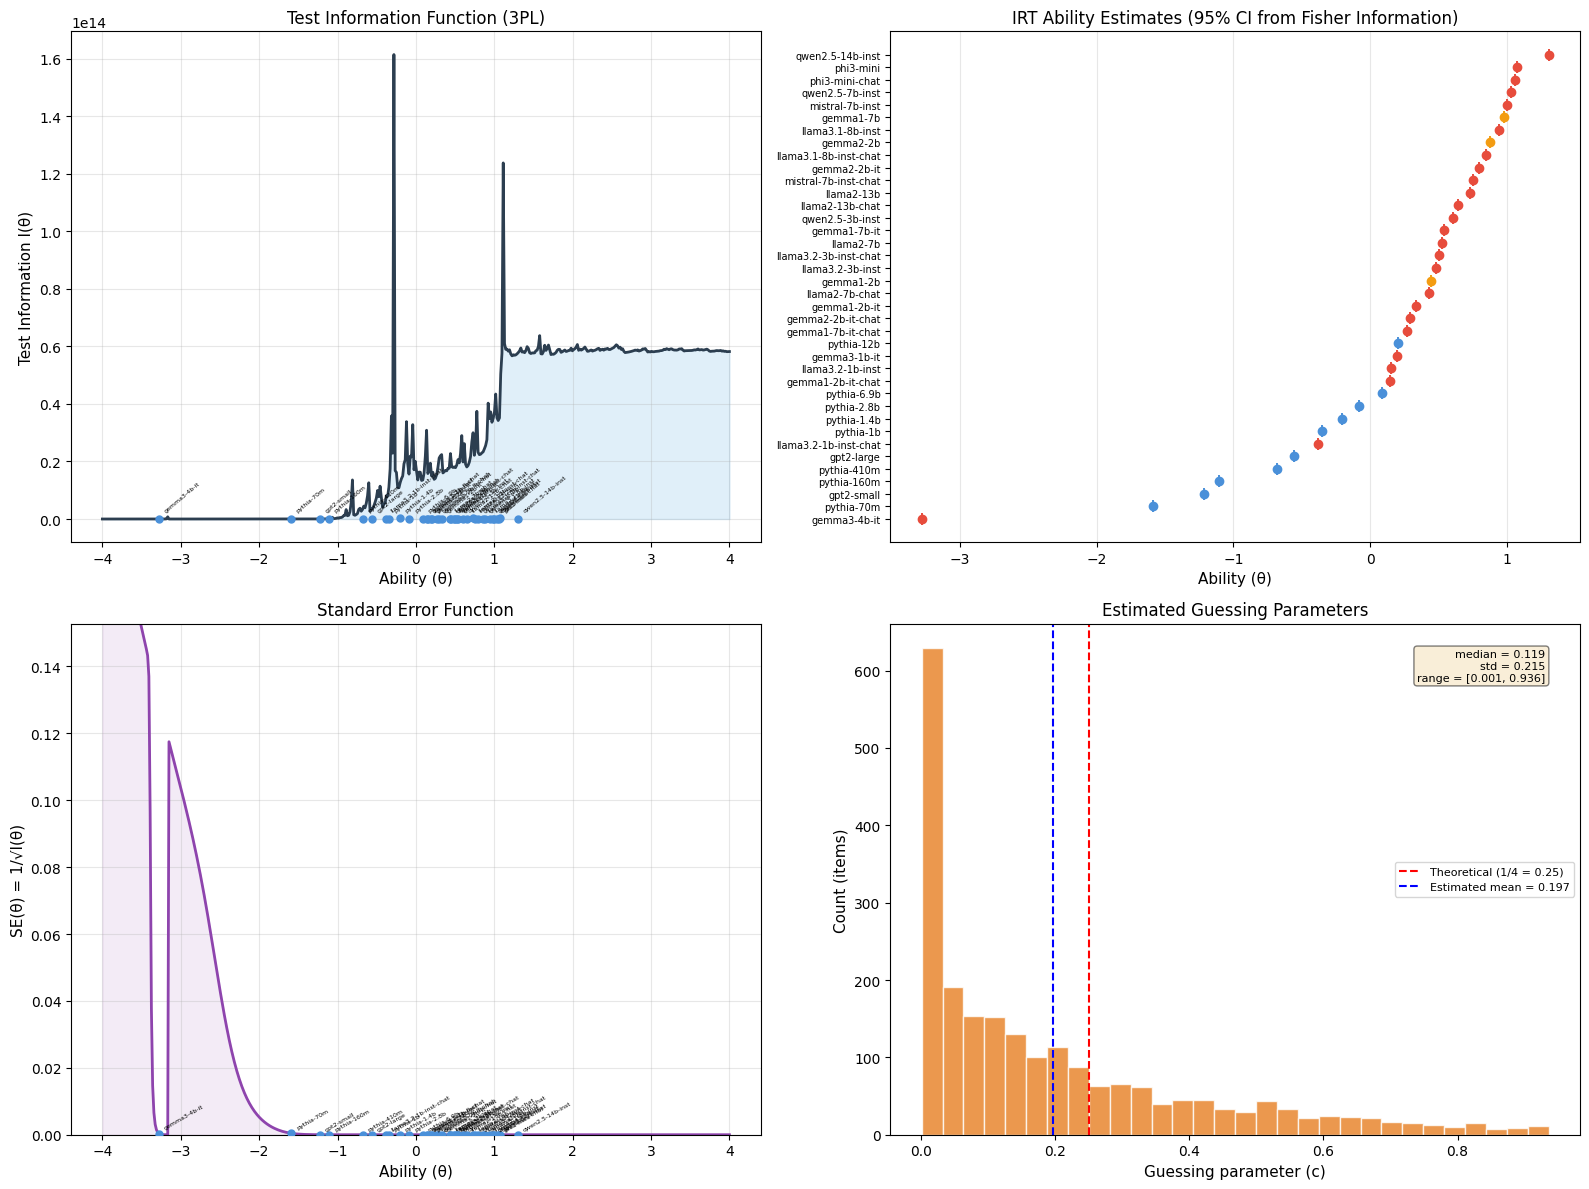

✅ Saved irt_analysis.png
✅ Saved irt_ability_estimates.csv
✅ Saved irt_item_parameters.csv


In [20]:
# ── Step 4: IRT Plots (Rasch sanity check) ────────────────────────
if len(samples_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    theta_grid = np.linspace(-4, 4, 500)

    # ── Plot 1: Test Information Function ──
    ax = axes[0, 0]
    I_total = test_information(theta_grid, a_params, b_params, c_params)
    ax.plot(theta_grid, I_total, color="#2C3E50", linewidth=2)
    ax.fill_between(theta_grid, I_total, alpha=0.15, color="#3498DB")

    for idx in range(n_models):
        t = thetas[idx]
        I_at_t = test_information(np.array([t]), a_params, b_params, c_params)[0]
        color = "#E74C3C" if t > 1.5 else "#4A90D9"
        ax.plot(t, I_at_t, 'o', color=color, markersize=5, zorder=3)
        ax.annotate(model_names[idx], (t, I_at_t), fontsize=4.5,
                   rotation=40, xytext=(3, 5), textcoords="offset points")

    ax.set_xlabel("Ability (θ)", fontsize=11)
    ax.set_ylabel("Test Information I(θ)", fontsize=11)
    ax.set_title("Test Information Function (Rasch/1PL)", fontsize=12)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: Ability estimates with IRT CIs ──
    ax = axes[0, 1]
    order = np.argsort(thetas)
    y_pos = np.arange(len(order))

    colors = []
    for idx in order:
        name = model_names[idx]
        if any(tag in name for tag in ["pythia", "gpt2"]):
            colors.append("#4A90D9")
        elif "gemma" in name and "it" not in name:
            colors.append("#F39C12")
        else:
            colors.append("#E74C3C")

    for i, idx in enumerate(order):
        ci = 1.96 * theta_ses[idx]
        ax.errorbar(thetas[idx], i, xerr=ci,
                   fmt='o', color=colors[i], markersize=6,
                   capsize=4, capthick=1.2, elinewidth=1.2, zorder=3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([model_names[idx] for idx in order], fontsize=7)
    ax.set_xlabel("Ability (θ)", fontsize=11)
    ax.set_title("IRT Ability Estimates (95% CI)", fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')

    # ── Plot 3: SE(θ) as a function of ability ──
    ax = axes[1, 0]
    SE_grid = 1.0 / np.sqrt(np.maximum(I_total, 1e-10))
    ax.plot(theta_grid, SE_grid, color="#8E44AD", linewidth=2)
    ax.fill_between(theta_grid, SE_grid, alpha=0.1, color="#8E44AD")

    for idx in range(n_models):
        t = thetas[idx]
        se = theta_ses[idx]
        color = "#E74C3C" if t > 1.5 else "#4A90D9"
        ax.plot(t, se, 'o', color=color, markersize=5, zorder=3)
        ax.annotate(model_names[idx], (t, se), fontsize=4.5,
                   rotation=30, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel("Ability (θ)", fontsize=11)
    ax.set_ylabel("SE(θ) = 1/√I(θ)", fontsize=11)
    ax.set_title("Standard Error Function", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, min(2.0, SE_grid[50:-50].max() * 1.3))

    # ── Plot 4: Distribution of b (difficulty) — key diagnostic ──
    ax = axes[1, 1]
    ax.hist(b_params, bins=30, color="#27AE60", edgecolor="white", alpha=0.8)
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1, label="θ = 0")
    ax.axvline(x=b_params.mean(), color="blue", linestyle="--", linewidth=1.5,
              label=f"Mean b = {b_params.mean():.2f}")

    # Mark where each model's θ falls
    for idx in range(n_models):
        ax.axvline(x=thetas[idx], color="#E74C3C", alpha=0.3, linewidth=0.8)

    ax.set_xlabel("Difficulty (b)", fontsize=11)
    ax.set_ylabel("Count (items)", fontsize=11)
    ax.set_title("Item Difficulty Distribution vs Model Abilities", fontsize=12)
    ax.legend(fontsize=8)
    ax.text(0.95, 0.95,
            f"n_items = {n_valid}\n"
            f"b range = [{b_params.min():.2f}, {b_params.max():.2f}]\n"
            f"Red lines = model θ values",
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/irt_rasch_analysis.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved irt_rasch_analysis.png")

    # Save IRT results
    irt_df = pd.DataFrame({
        "model": model_names,
        "theta": thetas,
        "se_theta": theta_ses,
        "ci95_lo": thetas - 1.96 * theta_ses,
        "ci95_hi": thetas + 1.96 * theta_ses,
    }).sort_values("theta")
    irt_df.to_csv(f"{SAVE_DIR}/irt_ability_estimates.csv", index=False)
    print(f"✅ Saved irt_ability_estimates.csv")

    item_params_df = pd.DataFrame({
        "item_id": valid_item_ids,
        "b_difficulty": b_params,
    })
    item_params_df.to_csv(f"{SAVE_DIR}/irt_item_parameters.csv", index=False)
    print(f"✅ Saved irt_item_parameters.csv")

## 8. Information Efficiency Analysis

The key saturation argument: while total $I(\theta)$ may be high everywhere (because we sum over ~2,376 items), the **information per item** collapses at high $\theta$. This means the benchmark is *inefficient* — you need thousands of items to distinguish strong models, but only a handful of well-targeted items could do the same job.

/tmp/ipykernel_18314/1796291121.py:23: RuntimeWarning: divide by zero encountered in divide
  return np.where(den > 1e-10, num / den, 0.0)


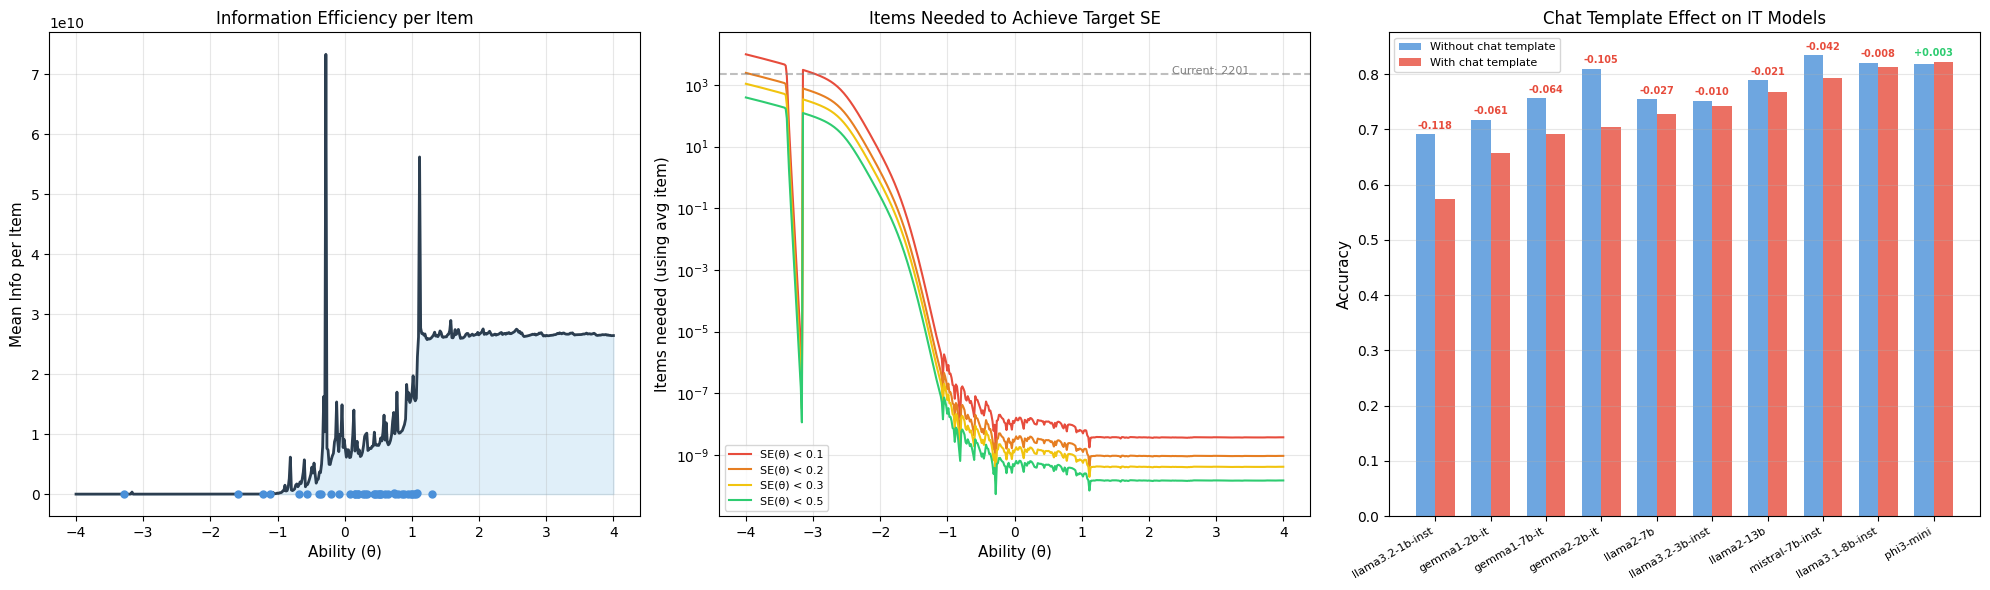

✅ Saved information_efficiency.png


In [21]:
# ── Information efficiency: per-item vs total ─────────────────────

if len(samples_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    theta_grid = np.linspace(-4, 4, 500)

    # Models in the saturation zone (high ability, low info)
    high_theta = thetas[thetas > 1.5]

    # ── Plot 1: Mean information PER ITEM ──
    ax = axes[0]
    I_total = test_information(theta_grid, a_params, b_params, c_params)
    I_per_item = I_total / n_valid  # average info contributed by each item

    ax.plot(theta_grid, I_per_item, color="#2C3E50", linewidth=2)
    ax.fill_between(theta_grid, I_per_item, alpha=0.15, color="#3498DB")

    # Mark model positions
    for idx in range(n_models):
        t = thetas[idx]
        I_at_t = test_information(np.array([t]), a_params, b_params, c_params)[0] / n_valid
        color = "#E74C3C" if t > 1.5 else "#4A90D9"
        ax.plot(t, I_at_t, 'o', color=color, markersize=5, zorder=3)

    ax.set_xlabel("Ability (θ)", fontsize=11)
    ax.set_ylabel("Mean Info per Item", fontsize=11)
    ax.set_title("Information Efficiency per Item", fontsize=12)
    ax.grid(True, alpha=0.3)

    # Annotate the peak-to-tail ratio
    peak_info = I_per_item.max()
    if len(high_theta) > 0:
        tail_info = test_information(np.array([high_theta.mean()]),
                                     a_params, b_params, c_params)[0] / n_valid
        ratio = peak_info / tail_info if tail_info > 0 else float('inf')
        ax.text(0.95, 0.95,
                f"Peak: {peak_info:.4f}\n"
                f"At saturation: {tail_info:.4f}\n"
                f"Ratio: {ratio:.0f}×",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # ── Plot 2: How many items needed for SE < target ──
    ax = axes[1]
    se_targets = [0.1, 0.2, 0.3, 0.5]  # target SE(θ) values
    colors_se = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71"]

    for se_target, color in zip(se_targets, colors_se):
        # n_items_needed = 1 / (se_target^2 * I_per_item)
        n_needed = 1.0 / (se_target**2 * np.maximum(I_per_item, 1e-10))
        n_needed = np.clip(n_needed, 0, n_valid * 5)  # cap for visualization
        ax.plot(theta_grid, n_needed, color=color, linewidth=1.5,
               label=f"SE(θ) < {se_target}")

    ax.axhline(y=n_valid, color="gray", linestyle="--", alpha=0.5)
    ax.text(3.5, n_valid * 1.05, f"Current: {n_valid}", fontsize=8,
           ha='right', color="gray")

    ax.set_xlabel("Ability (θ)", fontsize=11)
    ax.set_ylabel("Items needed (using avg item)", fontsize=11)
    ax.set_title("Items Needed to Achieve Target SE", fontsize=12)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Plot 3: Chat template boost comparison ──
    ax = axes[2]
    # Find pairs of models with/without chat template
    chat_pairs = []
    for m_name in model_names:
        if m_name.endswith("-chat"):
            base_name = m_name.replace("-chat", "")
            if base_name in model_names:
                base_idx = model_names.index(base_name)
                chat_idx = model_names.index(m_name)
                base_acc = np.nanmean(R[base_idx, :])
                chat_acc = np.nanmean(R[chat_idx, :])
                chat_pairs.append((base_name, base_acc, chat_acc))

    if chat_pairs:
        names, base_accs, chat_accs = zip(*chat_pairs)
        x = np.arange(len(names))
        w = 0.35
        ax.bar(x - w/2, base_accs, w, label="Without chat template",
               color="#4A90D9", alpha=0.8)
        ax.bar(x + w/2, chat_accs, w, label="With chat template",
               color="#E74C3C", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel("Accuracy", fontsize=11)
        ax.set_title("Chat Template Effect on IT Models", fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        for i, (_, ba, ca) in enumerate(chat_pairs):
            diff = ca - ba
            color = "#2ECC71" if diff > 0 else "#E74C3C"
            ax.text(i, max(ba, ca) + 0.01, f"{diff:+.3f}",
                   ha='center', fontsize=7, color=color, fontweight='bold')
    else:
        ax.text(0.5, 0.5, "No chat template pairs found yet.\n"
                "Run Section 3b with chat models first.",
                transform=ax.transAxes, fontsize=11, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax.set_title("Chat Template Effect", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/information_efficiency.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved information_efficiency.png")

In [ ]:
# ── Side-by-side: Accuracy (left) + IRT Ability Estimates (right) ──
# Filters to only models in the MODELS list

import matplotlib.pyplot as plt
import numpy as np

# Canonical model short names from the MODELS list
active_names = {m["short_name"] for m in MODELS}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ──────────────── Left: Accuracy vs Model Size (95% CI) ────────────────
ax = axes[0]
N_ITEMS = 2376

model_info = []
for m in MODELS:
    short = m["short_name"]
    params = m["params_B"]
    if short in model_acc.index:
        p = model_acc[short]
        se = np.sqrt(p * (1 - p) / N_ITEMS)
        ci95 = 1.96 * se
        is_base = any(tag in short for tag in ["pythia", "gpt2"])
        is_instruct = not is_base
        model_info.append((params, p, ci95, short, is_base, is_instruct))

model_info.sort(key=lambda x: x[0])

for label, color, marker, sel in [
    ("Base (Pythia)", "#4A90D9", "o", lambda b, i: b),
    ("Instruction-tuned", "#E74C3C", "^", lambda b, i: i),
]:
    subset = [(p, acc, ci, n) for p, acc, ci, n, b, i in model_info if sel(b, i)]
    if not subset:
        continue
    ps, accs, cis, names = zip(*subset)
    ax.errorbar(ps, accs, yerr=cis, fmt=marker, color=color,
               markersize=7, capsize=3, capthick=1, elinewidth=1,
               label=label, zorder=3, alpha=0.85)
    for p, a, n in zip(ps, accs, names):
        ax.annotate(n, (p, a), fontsize=6, rotation=25,
                   xytext=(4, 6), textcoords="offset points", alpha=0.8)

# Shade saturation band
high_acc = [acc for _, acc, _, _, _, _ in model_info if acc > 0.75]
if len(high_acc) >= 2:
    band_lo = min(high_acc) - 0.02
    band_hi = min(1.0, max(high_acc) + 0.02)
    ax.axhspan(band_lo, band_hi, alpha=0.08, color="#E74C3C",
              label=f"Saturation band ({len(high_acc)} models)")

ax.set_xscale("log")
ax.set_xlabel("Parameters (B)", fontsize=11)
ax.set_ylabel("ARC-Easy Accuracy", fontsize=11)
ax.set_title("Accuracy vs Model Size (95% CI)", fontsize=12)
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3)
ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.4)
ax.text(0.08, 0.26, "random (25%)", fontsize=7, color="gray", alpha=0.6)
ax.set_ylim(0.15, 1.02)

# ──────────────── Right: IRT Ability Estimates (95% CI) ────────────────
ax = axes[1]

# Filter to only active models
mask = [i for i, name in enumerate(model_names) if name in active_names]
filt_thetas = thetas[mask]
filt_ses = theta_ses[mask]
filt_names = [model_names[i] for i in mask]

order = np.argsort(filt_thetas)
for rank, idx in enumerate(order):
    name = filt_names[idx]
    ci = 1.96 * filt_ses[idx]
    color = "#4A90D9" if any(tag in name for tag in ["pythia", "gpt2"]) else "#E74C3C"
    ax.errorbar(filt_thetas[idx], rank, xerr=ci,
               fmt='o', color=color, markersize=6,
               capsize=4, capthick=1.2, elinewidth=1.2, zorder=3)

ax.set_yticks(range(len(order)))
ax.set_yticklabels([filt_names[idx] for idx in order], fontsize=7)
ax.set_xlabel("Ability (θ)", fontsize=11)
ax.set_title("IRT Ability Estimates (95% CI, Rasch)", fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/accuracy_vs_ability.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved accuracy_vs_ability.png")

In [ ]:
# ── Side-by-side: Item Information Efficiency (left) + Items Needed for Target SE (right) ──

import matplotlib.pyplot as plt
import numpy as np

active_names = {m["short_name"] for m in MODELS}
mask = [i for i, name in enumerate(model_names) if name in active_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
theta_grid = np.linspace(-4, 4, 500)

I_total = test_information(theta_grid, a_params, b_params, c_params)
I_per_item = I_total / n_valid

# ──────────────── Left: Mean Information per Item + Difficulty Histogram ────────────────
ax = axes[0]
ax.plot(theta_grid, I_per_item, color="#2C3E50", linewidth=2, zorder=4, label="Mean info/item")
ax.fill_between(theta_grid, I_per_item, alpha=0.15, color="#3498DB", zorder=2)

for idx in mask:
    t = thetas[idx]
    I_at_t = test_information(np.array([t]), a_params, b_params, c_params)[0] / n_valid
    color = "#E74C3C" if any(tag in model_names[idx] for tag in ["inst", "phi", "mistral"]) else "#4A90D9"
    ax.plot(t, I_at_t, 'o', color=color, markersize=5, zorder=5)
    ax.annotate(model_names[idx], (t, I_at_t), fontsize=5,
               rotation=30, xytext=(3, 5), textcoords="offset points", alpha=0.8)

# Peak-to-tail annotation
peak_info = I_per_item.max()
filt_thetas = thetas[mask]
high_theta = filt_thetas[filt_thetas > 1.5]
if len(high_theta) > 0:
    tail_info = test_information(np.array([high_theta.mean()]),
                                 a_params, b_params, c_params)[0] / n_valid
    ratio = peak_info / tail_info if tail_info > 0 else float('inf')
    ax.text(0.95, 0.95,
            f"Peak: {peak_info:.4f}\n"
            f"At saturation: {tail_info:.4f}\n"
            f"Ratio: {ratio:.0f}×",
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
            zorder=6)

ax.set_xlabel("Ability (θ) / Difficulty (β)", fontsize=11)
ax.set_ylabel("Mean Info per Item", fontsize=11, color="#2C3E50")
ax.tick_params(axis='y', labelcolor="#2C3E50")
ax.set_title("Information Efficiency + Item Difficulty Distribution", fontsize=12)
ax.grid(True, alpha=0.3)

# Overlay: item difficulty histogram on twin axis
ax2 = ax.twinx()
ax2.hist(b_params, bins=40, color="#27AE60", edgecolor="white",
         alpha=0.25, zorder=1, label="Item β distribution")
ax2.set_ylabel("Item count", fontsize=11, color="#27AE60", alpha=0.7)
ax2.tick_params(axis='y', labelcolor="#27AE60", alpha=0.7)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper left")

# ──────────────── Right: Items Needed for Target SE ────────────────
ax = axes[1]
se_targets = [0.1, 0.2, 0.3, 0.5]
colors_se = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71"]

for se_target, color in zip(se_targets, colors_se):
    n_needed = 1.0 / (se_target**2 * np.maximum(I_per_item, 1e-10))
    n_needed = np.clip(n_needed, 0, n_valid * 5)
    ax.plot(theta_grid, n_needed, color=color, linewidth=1.5,
           label=f"SE(θ) < {se_target}")

ax.axhline(y=n_valid, color="gray", linestyle="--", alpha=0.5)
ax.text(3.5, n_valid * 1.05, f"Current: {n_valid}", fontsize=8,
       ha='right', color="gray")

# Mark filtered model positions on the SE=0.2 curve
for idx in mask:
    t = thetas[idx]
    I_at_t = test_information(np.array([t]), a_params, b_params, c_params)[0] / n_valid
    n_at_t = 1.0 / (0.2**2 * max(I_at_t, 1e-10))
    n_at_t = min(n_at_t, n_valid * 5)
    ax.plot(t, n_at_t, 'o', color="#2C3E50", markersize=4, zorder=3, alpha=0.6)

ax.set_xlabel("Ability (θ)", fontsize=11)
ax.set_ylabel("Items needed (using avg item)", fontsize=11)
ax.set_title("Items Needed to Achieve Target SE", fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/info_efficiency_and_items_needed.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved info_efficiency_and_items_needed.png")